# Value at Risk (VaR) and Expected Shortfall (CVaR) via Monte Carlo Simulation

**Author:** Florian Ebner  
**Context:** Quantitative Risk Analysis – Portfolio Risk Measurement

---

## Overview of this Notebook

This notebook implements a **Monte Carlo-based Value at Risk (VaR)** and **Conditional Value at Risk (CVaR / Expected Shortfall)** framework for a multi-asset equity portfolio.

### What is Value at Risk?

Value at risk (VaR) is a measure of the risk of loss of investment/capital. It estimates how much a set of investments might lose (with a given probability), given normal market conditions, in a set time period such as a day. VaR is typically used by firms and regulators in the financial industry to gauge the amount of assets needed to cover possible losses. It essentially answers the question:  
> *"What is the maximum loss I will NOT exceed with x% probability over the next n days?"*

Example: A **1-day VaR of €10,000 at 99% confidence** means:  
On a typical trading day, there is only a **1% chance** of losing more than €10,000.

### Why do i use a Monte Carlo Simulation in this Notebook?

There are three standard approaches to calculate a VaR:
1. **Historical Simulation** – uses past returns directly
2. **Parametric (Variance-Covariance)** – assumes normally distributed returns
3. **Monte Carlo Simulation** – simulates thousands of possible future return paths

Monte Carlo is considered the most flexible approach: it can model **non-linear instruments**, **fat tails**, and **complex correlations** between assets. This is why it is the standard in bank trading desks and risk departments and also the reason i am using it here.

### Regulatory Context (Basel III / FRTB)

Under **Basel III** and the **Fundamental Review of the Trading Book (FRTB)**, banks are required to:
- Report **Expected Shortfall (ES)** instead of VaR as the primary risk metric (since ES better captures tail risk)
- Use a **97.5% confidence level** for ES (equivalent to 99% VaR in practice)
- **Backtest** VaR models regularly to validate their accuracy

This notebook implements all three: VaR, ES, and a basic **Kupiec backtest**.

---

## Step 1: Imports and Configuration

I use:
- `numpy` for numerical simulation
- `pandas` for data handling
- `matplotlib` for visualization
- `scipy.stats` for statistical tests (Kupiec backtest)

In a production setting, `yfinance` would be used to pull real market data. Here i use **synthetic correlated returns** that replicate realistic equity behavior (mean ~0, annualized volatility ~20%).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

# ── Reproducibility ───────────────────────────────────────────────────────────
np.random.seed(42)

# ── Simulation Parameters ─────────────────────────────────────────────────────
N_SIMULATIONS   = 10_000   # number of Monte Carlo paths
N_DAYS_HISTORY  = 504      # ~2 years of trading days for parameter estimation
HOLDING_PERIOD  = 1        # 1-day VaR (Basel standard for market risk)
CONFIDENCE_VaR  = 0.99     # 99% VaR  (historical Basel II standard)
CONFIDENCE_ES   = 0.975    # 97.5% ES (Basel III / FRTB standard)
PORTFOLIO_VALUE = 1_000_000  # €1,000,000 portfolio

# ── Plot Style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

print('Configuration loaded.')
print(f'  Portfolio value : €{PORTFOLIO_VALUE:,.0f}')
print(f'  Simulations     : {N_SIMULATIONS:,}')
print(f'  VaR confidence  : {CONFIDENCE_VaR*100:.0f}%')
print(f'  ES  confidence  : {CONFIDENCE_ES*100:.1f}%')

Configuration loaded.
  Portfolio value : €1,000,000
  Simulations     : 10,000
  VaR confidence  : 99%
  ES  confidence  : 97.5%


## Step 2: Define the Portfolio and Generate Synthetic Market Data

Here i construct a **5-asset equity portfolio** representative of a diversified European equity book:

| Asset | Weight | Proxy for |
|-------|--------|-----------|
| Asset A | 30% | Large-cap (e.g. SAP) |
| Asset B | 25% | Financial (e.g. Deutsche Bank) |
| Asset C | 20% | Industrial (e.g. Siemens) |
| Asset D | 15% | Tech/Growth |
| Asset E | 10% | Defensive/Utility |

### Synthetic Data Generation

Real returns are **correlated** across assets (e.g. all stocks tend to fall together in a market crash). I model this using a **multivariate normal distribution** parameterized by:
- A **mean return vector** (μ) – daily expected return per asset
- A **covariance matrix** (Σ) – capturing both individual volatilities and cross-asset correlations

I use a **Cholesky decomposition** of the correlation matrix to generate correlated random samples, as this is considered to be standard practice in Monte Carlo risk engines.

In [2]:
# ── Portfolio Weights ─────────────────────────────────────────────────────────
assets  = ['Asset A', 'Asset B', 'Asset C', 'Asset D', 'Asset E']
weights = np.array([0.30, 0.25, 0.20, 0.15, 0.10])
assert np.isclose(weights.sum(), 1.0), 'Weights must sum to 1'

n_assets = len(assets)

# ── Annual Parameters (realistic equity assumptions) ─────────────────────────
annual_returns = np.array([0.08, 0.06, 0.07, 0.12, 0.04])  # annualized mean returns
annual_vols    = np.array([0.18, 0.28, 0.20, 0.32, 0.14])  # annualized volatilities

# ── Scale to Daily ────────────────────────────────────────────────────────────
TRADING_DAYS   = 252
daily_returns  = annual_returns / TRADING_DAYS
daily_vols     = annual_vols    / np.sqrt(TRADING_DAYS)

# ── Correlation Matrix ────────────────────────────────────────────────────────
# Assets tend to move together (positive correlation), but not perfectly.
# Financials (B) and Industrials (C) are more correlated with each other.
corr_matrix = np.array([
    [1.00, 0.55, 0.60, 0.45, 0.30],  # Asset A
    [0.55, 1.00, 0.65, 0.40, 0.20],  # Asset B
    [0.60, 0.65, 1.00, 0.50, 0.35],  # Asset C
    [0.45, 0.40, 0.50, 1.00, 0.25],  # Asset D
    [0.30, 0.20, 0.35, 0.25, 1.00],  # Asset E
])

# ── Build Covariance Matrix from Correlations and Volatilities ─────────────
# Σ_ij = ρ_ij * σ_i * σ_j
cov_matrix = np.outer(daily_vols, daily_vols) * corr_matrix

# ── Simulate Historical Returns via Cholesky Decomposition ───────────────────
# Cholesky: Σ = L * L^T  →  generate Z ~ N(0,I), then X = μ + L*Z ~ N(μ, Σ)
L = np.linalg.cholesky(cov_matrix)
Z = np.random.standard_normal((N_DAYS_HISTORY, n_assets))
historical_returns = daily_returns + Z @ L.T

df_returns = pd.DataFrame(historical_returns, columns=assets)

print('Historical return statistics (daily):')
print(df_returns.describe().round(5))

Historical return statistics (daily):
         Asset A    Asset B    Asset C    Asset D    Asset E
count  504.00000  504.00000  504.00000  504.00000  504.00000
mean     0.00086    0.00076    0.00086    0.00116    0.00100
std      0.01096    0.01802    0.01258    0.01940    0.00877
min     -0.03033   -0.05320   -0.03764   -0.05641   -0.02903
25%     -0.00623   -0.01028   -0.00772   -0.01164   -0.00501
50%      0.00132    0.00056    0.00141    0.00272    0.00042
75%      0.00785    0.01193    0.01023    0.01379    0.00686
max      0.03652    0.05007    0.03609    0.05491    0.03060


## Step 3: Estimate Parameters from Historical Data

In a real risk engine, parameters are **estimated from historical market data** – not hard-coded. I try to replicate that here by fitting the mean vector and covariance matrix from our simulated history.

This is important because:
- Risk models must be **data-driven**, not assumption-driven
- The covariance matrix captures the **current correlation regime** of the market
- Regulators require models to be calibrated to at least **1 year of data**

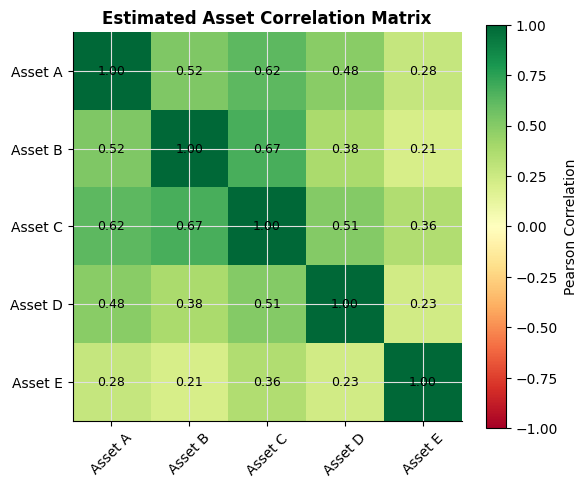

Covariance matrix estimated from 504 trading days.


In [3]:
# ── Estimate Parameters from Historical Returns ───────────────────────────────
mu_hat    = df_returns.mean().values           # estimated daily mean returns
cov_hat   = df_returns.cov().values            # estimated covariance matrix

# ── Visualise the Correlation Matrix ─────────────────────────────────────────
corr_hat = df_returns.corr().values

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_hat, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Pearson Correlation')
ax.set_xticks(range(n_assets)); ax.set_yticks(range(n_assets))
ax.set_xticklabels(assets, rotation=45)
ax.set_yticklabels(assets)
for i in range(n_assets):
    for j in range(n_assets):
        ax.text(j, i, f'{corr_hat[i,j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('Estimated Asset Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Covariance matrix estimated from', N_DAYS_HISTORY, 'trading days.')

## Step 4: Monte Carlo Simulation of Portfolio Returns

This is the core of the model. In the following steps i simulate **10,000 possible outcomes** for the portfolio over the next trading day.

### How it works:
1. Draw 10,000 random return vectors from `N(μ, Σ)` using the estimated parameters
2. For each scenario, compute the **portfolio return** as the weighted sum of asset returns
3. Convert portfolio returns to **P&L in euros** (Profit & Loss)

The resulting distribution of 10,000 P&L values represents the **view of all possible outcomes** tomorrow, from the best to the worst case. VaR and CVaR can then be simply read off this distribution.

In [4]:
# ── Monte Carlo Simulation ────────────────────────────────────────────────────
# Draw N_SIMULATIONS correlated return vectors from N(μ̂, Σ̂)
simulated_returns = np.random.multivariate_normal(
    mean=mu_hat,
    cov=cov_hat,
    size=N_SIMULATIONS
)  # shape: (10000, 5)

# ── Portfolio Return per Scenario ─────────────────────────────────────────────
# portfolio_return[i] = w^T * r[i]  (dot product of weights and asset returns)
portfolio_returns = simulated_returns @ weights  # shape: (10000,)

# ── Convert to P&L in Euros ───────────────────────────────────────────────────
pnl = portfolio_returns * PORTFOLIO_VALUE  # shape: (10000,)

print(f'Simulated {N_SIMULATIONS:,} portfolio P&L scenarios.')
print(f'  Mean P&L   : €{pnl.mean():+,.0f}')
print(f'  Std Dev    : €{pnl.std():,.0f}')
print(f'  Min P&L    : €{pnl.min():+,.0f}')
print(f'  Max P&L    : €{pnl.max():+,.0f}')

Simulated 10,000 portfolio P&L scenarios.
  Mean P&L   : €+898
  Std Dev    : €11,110
  Min P&L    : €-42,220
  Max P&L    : €+45,281


## Step 5: Compute VaR and CVaR (Expected Shortfall)

### Value at Risk (VaR)
VaR at confidence level α is the **α-quantile of losses**:  
$$\text{VaR}_{\alpha} = -\text{Quantile}_{1-\alpha}(\text{P\&L})$$

At 99% confidence: we sort the 10,000 P&L values and take the **100th worst outcome** (1% of 10,000).

### Conditional VaR / Expected Shortfall (CVaR / ES)
CVaR answers: *"Given that we ARE in the tail, what is the average loss?"*  
$$\text{CVaR}_{\alpha} = -\mathbb{E}[\text{P\&L} \mid \text{P\&L} \leq -\text{VaR}_{\alpha}]$$

CVaR is **always larger than VaR** and is the metric required under **Basel III/FRTB** because it better captures the severity of tail events (e.g. the 2008 financial crisis).

In [5]:
# ── VaR Calculation ───────────────────────────────────────────────────────────
VaR_99  = -np.percentile(pnl, (1 - CONFIDENCE_VaR) * 100)
VaR_95  = -np.percentile(pnl, 5.0)

# ── CVaR / Expected Shortfall ─────────────────────────────────────────────────
# Average of all losses WORSE than VaR
threshold_ES     = np.percentile(pnl, (1 - CONFIDENCE_ES) * 100)
CVaR_975         = -pnl[pnl <= threshold_ES].mean()

# Also compute CVaR at 99% for comparison
threshold_99     = np.percentile(pnl, 1.0)
CVaR_99          = -pnl[pnl <= threshold_99].mean()

print('══════════════════════════════════════════════')
print(f'  Portfolio Value              : €{PORTFOLIO_VALUE:>12,.0f}')
print('══════════════════════════════════════════════')
print(f'  VaR  (95%, 1-day)            : €{VaR_95:>12,.0f}')
print(f'  VaR  (99%, 1-day)            : €{VaR_99:>12,.0f}')
print('──────────────────────────────────────────────')
print(f'  CVaR (97.5%, 1-day) [Basel]  : €{CVaR_975:>12,.0f}')
print(f'  CVaR (99%,   1-day)          : €{CVaR_99:>12,.0f}')
print('══════════════════════════════════════════════')
print()
print(f'  VaR (99%) as % of portfolio  : {VaR_99/PORTFOLIO_VALUE*100:.2f}%')
print(f'  ES  (97.5%) as % of portfolio: {CVaR_975/PORTFOLIO_VALUE*100:.2f}%')

══════════════════════════════════════════════
  Portfolio Value              : €   1,000,000
══════════════════════════════════════════════
  VaR  (95%, 1-day)            : €      17,376
  VaR  (99%, 1-day)            : €      24,116
──────────────────────────────────────────────
  CVaR (97.5%, 1-day) [Basel]  : €      24,506
  CVaR (99%,   1-day)          : €      27,701
══════════════════════════════════════════════

  VaR (99%) as % of portfolio  : 2.41%
  ES  (97.5%) as % of portfolio: 2.45%


## Step 6: Visualisation of the P&L Distribution

This plot is the key output of the model. It shows:
- The **full distribution** of simulated portfolio P&L values
- The **VaR threshold** (vertical line) – losses to the left exceed VaR
- The **Expected Shortfall region** (shaded area) – the average loss in this region is CVaR

Note how the distribution has a slight **negative skew** – a realistic property of equity portfolios.

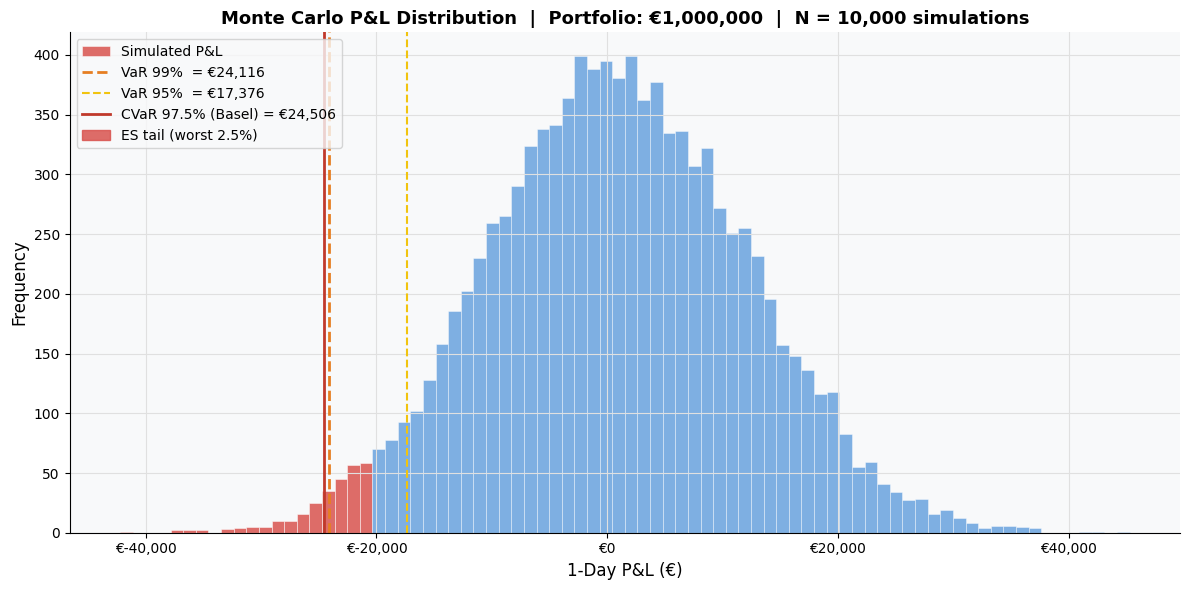

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

# ── Histogram of P&L ─────────────────────────────────────────────────────────
n_bins = 80
counts, bin_edges, patches = ax.hist(
    pnl, bins=n_bins, color='#4a90d9', alpha=0.7,
    edgecolor='white', linewidth=0.4, label='Simulated P&L'
)

# ── Highlight Tail (losses beyond 97.5% CVaR threshold) ──────────────────────
for patch, left_edge in zip(patches, bin_edges):
    if left_edge < threshold_ES:
        patch.set_facecolor('#d9534f')
        patch.set_alpha(0.85)

# ── VaR Lines ────────────────────────────────────────────────────────────────
ax.axvline(-VaR_99,   color='#e67e22', lw=2.0, ls='--',
           label=f'VaR 99%  = €{VaR_99:,.0f}')
ax.axvline(-VaR_95,   color='#f1c40f', lw=1.5, ls='--',
           label=f'VaR 95%  = €{VaR_95:,.0f}')
ax.axvline(-CVaR_975, color='#c0392b', lw=2.0, ls='-',
           label=f'CVaR 97.5% (Basel) = €{CVaR_975:,.0f}')

# ── Labels ────────────────────────────────────────────────────────────────────
ax.set_xlabel('1-Day P&L (€)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title(
    f'Monte Carlo P&L Distribution  |  Portfolio: €{PORTFOLIO_VALUE:,.0f}  |  '
    f'N = {N_SIMULATIONS:,} simulations',
    fontsize=13, fontweight='bold'
)
tail_patch = mpatches.Patch(color='#d9534f', alpha=0.85, label='ES tail (worst 2.5%)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [tail_patch], fontsize=10, loc='upper left')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
plt.tight_layout()
plt.savefig('var_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7: VaR Contribution by Asset

A critical question in portfolio risk management is: **which asset contributes most to the portfolio's VaR?**

Here i compute **Component VaR** using the **delta-normal approximation**:
$$\text{Component VaR}_i = w_i \cdot (\Sigma w)_i / \sigma_p \cdot \text{VaR}_p$$

where σ_p is the portfolio volatility. This tells risk managers where to **hedge** or **reduce exposure**.

Component VaR Breakdown (99%, 1-day):
  Asset  Weight  Component VaR (€)  % of Total VaR
Asset A    0.30            6175.29           24.22
Asset B    0.25            8782.67           34.44
Asset C    0.20            5004.28           19.62
Asset D    0.15            4741.91           18.60
Asset E    0.10             796.40            3.12

Total Component VaR: €25,501


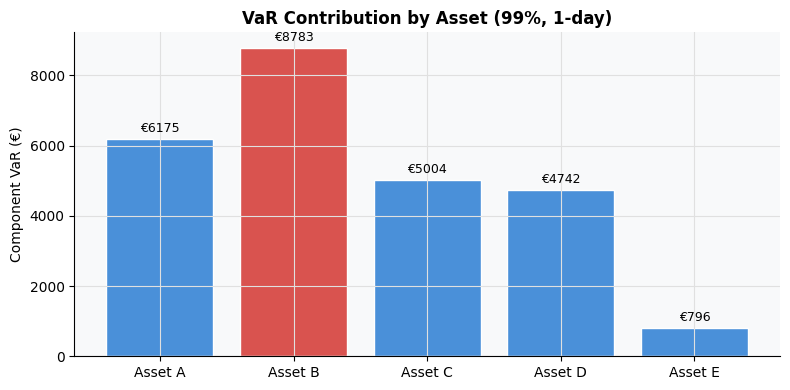

In [7]:
# ── Component VaR ─────────────────────────────────────────────────────────────
portfolio_var_scalar = weights @ cov_hat @ weights          # portfolio variance
portfolio_vol        = np.sqrt(portfolio_var_scalar)        # portfolio daily vol
marginal_var         = cov_hat @ weights / portfolio_vol    # marginal contribution

z_99 = stats.norm.ppf(CONFIDENCE_VaR)  # z-score for 99% = 2.326
component_var = weights * marginal_var * z_99 * PORTFOLIO_VALUE

df_component = pd.DataFrame({
    'Asset':         assets,
    'Weight':        weights,
    'Component VaR (€)': component_var,
    '% of Total VaR': component_var / component_var.sum() * 100
})

print('Component VaR Breakdown (99%, 1-day):')
print(df_component.to_string(index=False, float_format='%.2f'))
print(f'\nTotal Component VaR: €{component_var.sum():,.0f}')

# ── Bar Chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d9534f' if v == max(component_var) else '#4a90d9' for v in component_var]
bars = ax.bar(assets, component_var, color=colors, edgecolor='white')
ax.bar_label(bars, fmt='€%.0f', padding=3, fontsize=9)
ax.set_ylabel('Component VaR (€)')
ax.set_title('VaR Contribution by Asset (99%, 1-day)', fontweight='bold')
plt.tight_layout()
plt.savefig('component_var.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: VaR Backtesting – Kupiec Test

A VaR model is only as good as its **predictive accuracy**. **Backtesting** compares the model's VaR predictions against actual historical losses.

### Logic:
- A 99% VaR model should be **breached** (actual loss > VaR) on approximately **1% of trading days**
- Over 252 trading days, we expect ~**2–3 breaches**
- Too many breaches → model **underestimates** risk (dangerous!)
- Too few breaches → model **overestimates** risk (expensive capital allocation)

### Kupiec Proportion of Failures (POF) Test:
The Kupiec test checks whether the observed breach rate is statistically consistent with the expected rate using a **likelihood ratio test**:
$$LR_{POF} = -2 \ln\left[\frac{(1-p)^{T-N} p^N}{(1-N/T)^{T-N}(N/T)^N}\right] \sim \chi^2_1$$

If p-value > 0.05 → model is **not rejected** at 5% significance.

Backtest Period  : 252 trading days
Expected breaches: 2.5  (1% × 252)
Actual  breaches : 2  (rate: 0.79%)

Kupiec POF Test:
  LR statistic : 0.1166
  p-value      : 0.7327
  Model        : NOT REJECTED ✓  (at 5% significance)


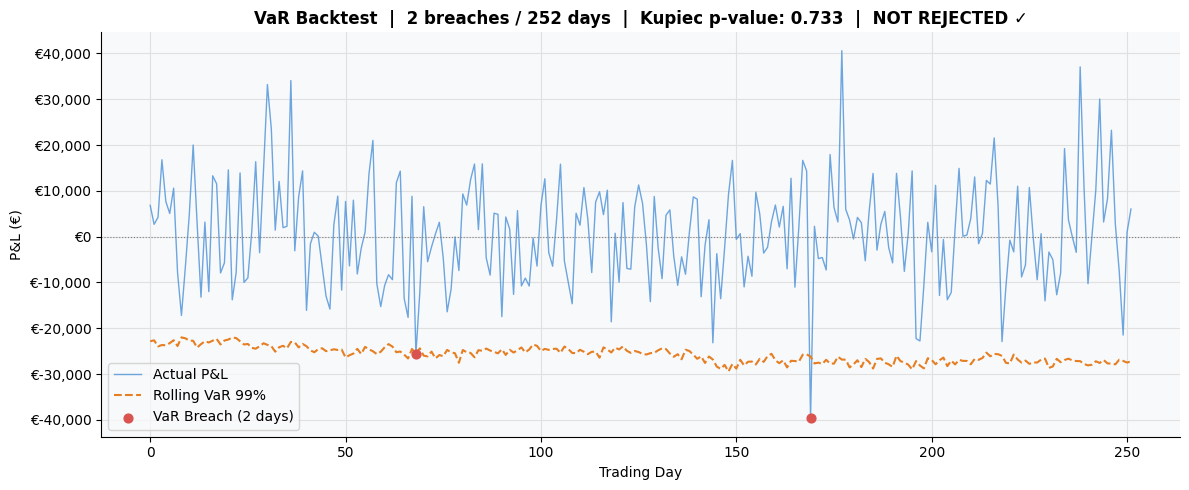

In [8]:
# ── Simulate "Actual" Returns for Backtesting ─────────────────────────────────
# Generate a new out-of-sample history (simulates what actually happened)
np.random.seed(99)
T_backtest     = 252  # 1 year of trading days
actual_returns = np.random.multivariate_normal(mu_hat, cov_hat, size=T_backtest)
actual_pnl     = (actual_returns @ weights) * PORTFOLIO_VALUE

# ── Rolling VaR (re-estimated each day from preceding 126-day window) ─────────
# In practice, banks re-estimate VaR daily with a rolling window
window_size = 126   # ~6 months
rolling_var = []

all_returns_combined = np.vstack([historical_returns, actual_returns])

for t in range(T_backtest):
    window_ret = all_returns_combined[t : t + window_size]
    sim_r = np.random.multivariate_normal(
        window_ret.mean(axis=0),
        np.cov(window_ret.T),
        size=5000
    ) @ weights * PORTFOLIO_VALUE
    rolling_var.append(-np.percentile(sim_r, 1.0))

rolling_var = np.array(rolling_var)

# ── Count Breaches ────────────────────────────────────────────────────────────
breaches     = actual_pnl < -rolling_var
N_breaches   = breaches.sum()
breach_rate  = N_breaches / T_backtest
expected_N   = T_backtest * (1 - CONFIDENCE_VaR)

print(f'Backtest Period  : {T_backtest} trading days')
print(f'Expected breaches: {expected_N:.1f}  ({(1-CONFIDENCE_VaR)*100:.0f}% × {T_backtest})')
print(f'Actual  breaches : {N_breaches}  (rate: {breach_rate*100:.2f}%)')

# ── Kupiec Test ───────────────────────────────────────────────────────────────
p    = 1 - CONFIDENCE_VaR   # expected breach probability
N, T = N_breaches, T_backtest

if N == 0:
    lr_stat  = -2 * (T * np.log(1 - p))
else:
    lr_stat  = -2 * (
        (T - N) * np.log(1 - p) + N * np.log(p)
        - (T - N) * np.log(1 - N/T) - N * np.log(N/T)
    )

p_value  = 1 - stats.chi2.cdf(lr_stat, df=1)
result   = 'NOT REJECTED ✓' if p_value > 0.05 else 'REJECTED ✗'

print(f'\nKupiec POF Test:')
print(f'  LR statistic : {lr_stat:.4f}')
print(f'  p-value      : {p_value:.4f}')
print(f'  Model        : {result}  (at 5% significance)')

# ── Visualise Backtest ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
days = np.arange(T_backtest)

ax.plot(days, actual_pnl, color='#4a90d9', lw=1.0, alpha=0.8, label='Actual P&L')
ax.plot(days, -rolling_var, color='#e67e22', lw=1.5, ls='--', label='Rolling VaR 99%')

breach_days = days[breaches]
ax.scatter(breach_days, actual_pnl[breaches],
           color='#d9534f', zorder=5, s=40, label=f'VaR Breach ({N_breaches} days)')

ax.axhline(0, color='grey', lw=0.8, ls=':')
ax.set_xlabel('Trading Day')
ax.set_ylabel('P&L (€)')
ax.set_title(f'VaR Backtest  |  {N_breaches} breaches / {T_backtest} days  '
             f'|  Kupiec p-value: {p_value:.3f}  |  {result}',
             fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
plt.tight_layout()
plt.savefig('backtest.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Multi-Day VaR Scaling

Regulators often require **10-day VaR** (Basel II market risk capital requirement).  
Under the assumption of i.i.d. (independent, identically distributed) returns:

$$\text{VaR}_{T-\text{day}} = \text{VaR}_{1-\text{day}} \times \sqrt{T}$$

This is the **square-root-of-time rule**. It's a simplification, in practice, volatility clustering (GARCH effects) means this underestimates multi-day risk during stress periods.

Multi-Day VaR Scaling (Square-Root-of-Time Rule):
   Horizon |     VaR 99% (€) |     CVaR 97.5% (€)
------------------------------------------------
  1 day(s) | €       24,116 | €          24,506
  2 day(s) | €       34,105 | €          34,656
  5 day(s) | €       53,924 | €          54,797
 10 day(s) | €       76,260 | €          77,494
 20 day(s) | €      107,848 | €         109,593


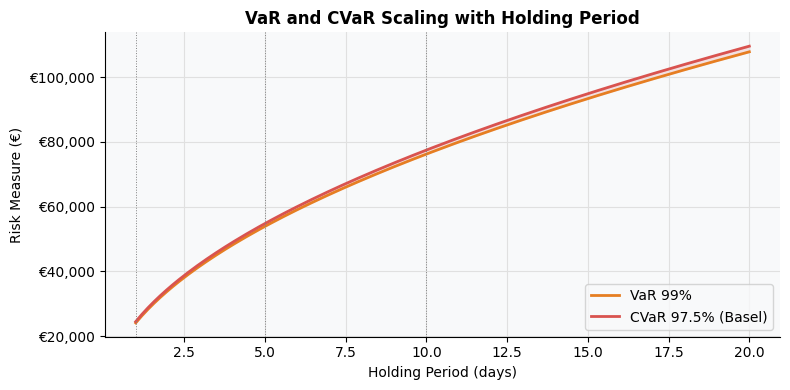

In [9]:
horizons = [1, 2, 5, 10, 20]

print('Multi-Day VaR Scaling (Square-Root-of-Time Rule):')
print(f'{"Horizon":>10} | {"VaR 99% (€)":>15} | {"CVaR 97.5% (€)":>18}')
print('-' * 48)
for h in horizons:
    var_h  = VaR_99  * np.sqrt(h)
    cvar_h = CVaR_975 * np.sqrt(h)
    print(f'{str(h)+" day(s)":>10} | €{var_h:>13,.0f} | €{cvar_h:>16,.0f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
h_range    = np.linspace(1, 20, 200)
var_scaled = VaR_99  * np.sqrt(h_range)
es_scaled  = CVaR_975 * np.sqrt(h_range)

ax.plot(h_range, var_scaled,  color='#e67e22', lw=2, label='VaR 99%')
ax.plot(h_range, es_scaled,   color='#d9534f', lw=2, label='CVaR 97.5% (Basel)')
ax.fill_between(h_range, var_scaled, es_scaled, alpha=0.15, color='#d9534f')

for h in [1, 5, 10]:
    ax.axvline(h, color='grey', lw=0.7, ls=':')

ax.set_xlabel('Holding Period (days)')
ax.set_ylabel('Risk Measure (€)')
ax.set_title('VaR and CVaR Scaling with Holding Period', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('var_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary & Results

This notebook implemented a complete Monte Carlo VaR framework including:

| Component | Description |
|-----------|-------------|
| **Monte Carlo Engine** | 10,000 correlated scenarios via Cholesky decomposition |
| **VaR (99%, 1-day)** | Maximum expected loss at 99% confidence |
| **CVaR / ES (97.5%)** | Basel III Expected Shortfall metric |
| **Component VaR** | Risk attribution by asset |
| **Kupiec Backtest** | Statistical validation of model accuracy |
| **Multi-Day Scaling** | √T rule for regulatory capital horizons |

### Key Takeaways for Risk Management:

1. **CVaR > VaR**: CVaR always exceeds VaR because it averages the entire tail – this is why Basel III replaced VaR with ES as the primary capital metric.
2. **Asset concentration matters**: Component VaR reveals that Asset B (Financial sector, highest volatility) disproportionately drives portfolio risk relative to its weight.
3. **Backtesting is non-negotiable**: The Kupiec test confirms whether the model is statistically well-calibrated, this means that a model that fails backtesting cannot be used for regulatory capital calculation.

### Extensions for Production Use:
- Replace synthetic data with live market data (`yfinance`, Bloomberg API, or internal data warehouse)
- Implement **GARCH volatility forecasting** for time-varying volatility
- Add **stressed VaR** (Basel 2.5 requirement): recalibrate to a 1-year stress period (e.g. 2008–2009)
- Extend to **non-equity asset classes**: FX, rates, credit spreads
- Implement **DCC-GARCH** for dynamic correlations